# 04 — Observing Efficiency, Night by Night

$$ \text{efficiency} = \frac{\text{time spent exposing}}{\text{first exposure start} \rightarrow \text{last exposure end}} \in [0, 1] $$

All programs count (survey, SN, GW). Nights straddle midnight, so timestamps are shifted back 12 h before dating. Nights with <10 exposures are dropped (a 1-exposure night is trivially 1.0). Context for reading the numbers: DECam readout is ~30 s, so a flawless 90 s-exposure night tops out near 90/120 = **0.75**.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/des-exposures.csv.gz')
df['dt'] = pd.to_datetime(df['datetime'], errors='coerce')
df = df[df['dt'].dt.year >= 2012]
df['night'] = (df['dt'] - pd.Timedelta(hours=12)).dt.date
df['end'] = df['dt'] + pd.to_timedelta(df['exptime'], unit='s')
len(df)

105748

In [4]:
nights = df.groupby('night').agg(
    n=('expnum', 'size'),
    observing_s=('exptime', 'sum'),
    start=('dt', 'min'),
    end=('end', 'max'),
)
nights['span_s'] = (nights['end'] - nights['start']).dt.total_seconds()
nights['efficiency'] = nights['observing_s'] / nights['span_s']
nights = nights[nights['n'] >= 10]

print(f"{len(nights)} nights   median efficiency {nights['efficiency'].median():.2f}")
nights[['n', 'observing_s', 'span_s', 'efficiency']].head()

705 nights   median efficiency 0.71


,n,observing_s,span_s,efficiency
night,,,,
2013-08-31,140,14635.0,26615.0,0.549878
2013-09-01,228,25345.0,36412.0,0.696062
2013-09-02,198,25595.0,36887.0,0.693876
2013-09-03,274,24660.0,34910.0,0.706388
2013-09-04,90,8100.0,13325.0,0.607880


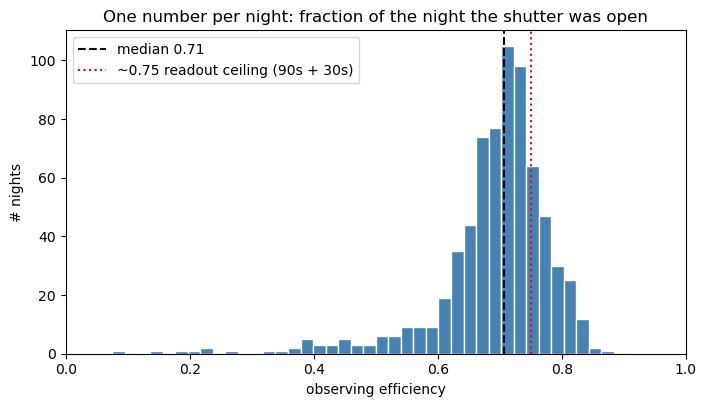

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.hist(nights['efficiency'], bins=40, color='steelblue', edgecolor='white')
ax.axvline(nights['efficiency'].median(), color='k', ls='--',
           label=f"median {nights['efficiency'].median():.2f}")
ax.axvline(0.75, color='red', ls=':', label='~0.75 readout ceiling (90s + 30s)')
ax.set_xlim(0, 1)
ax.set_xlabel('observing efficiency')
ax.set_ylabel('# nights')
ax.set_title('One number per night: fraction of the night the shutter was open')
ax.legend()
plt.show()

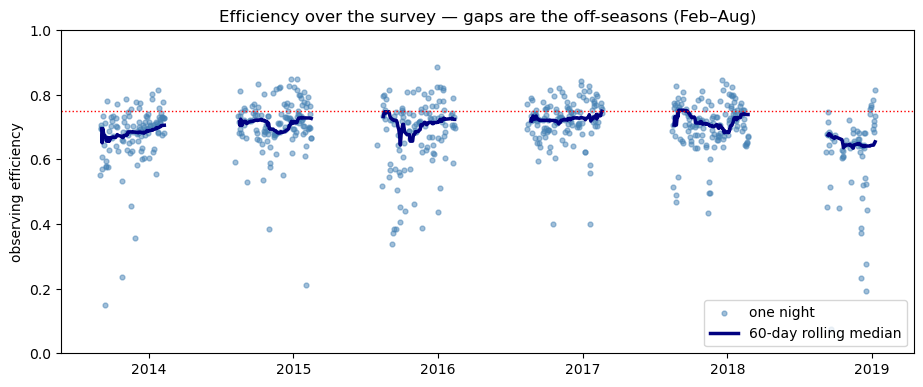

In [4]:
t = nights.reset_index()
t['night_dt'] = pd.to_datetime(t['night'])
t = t.sort_values('night_dt')
roll = t.set_index('night_dt')['efficiency'].rolling('60D', min_periods=5).median()

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.scatter(t['night_dt'], t['efficiency'], s=12, alpha=0.5, color='steelblue', label='one night')
ax.plot(roll.index, roll.values, color='navy', lw=2.5, label='60-day rolling median')
ax.axhline(0.75, color='red', ls=':', lw=1)
ax.set_ylim(0, 1)
ax.set_ylabel('observing efficiency')
ax.set_title('Efficiency over the survey — gaps are the off-seasons (Feb–Aug)')
ax.legend(loc='lower right')
plt.show()

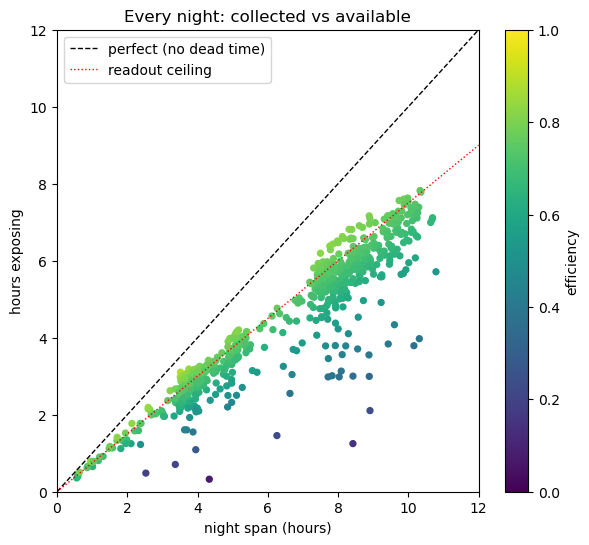

In [7]:
# hours observed vs hours available; distance below the diagonal = dead time
fig, ax = plt.subplots(figsize=(6.8, 6))
sc = ax.scatter(nights['span_s']/3600, nights['observing_s']/3600,
                c=nights['efficiency'], cmap='viridis', s=18, vmin=0, vmax=1)
lim = [0,12]
ax.plot(lim, lim, 'k--', lw=1, label='perfect (no dead time)')
ax.plot(lim, [0.75*x for x in lim], 'r:', lw=1, label='readout ceiling')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('night span (hours)')
ax.set_ylabel('hours exposing')
ax.set_title('Every night: collected vs available')
fig.colorbar(sc, label='efficiency')
ax.legend()
plt.show()

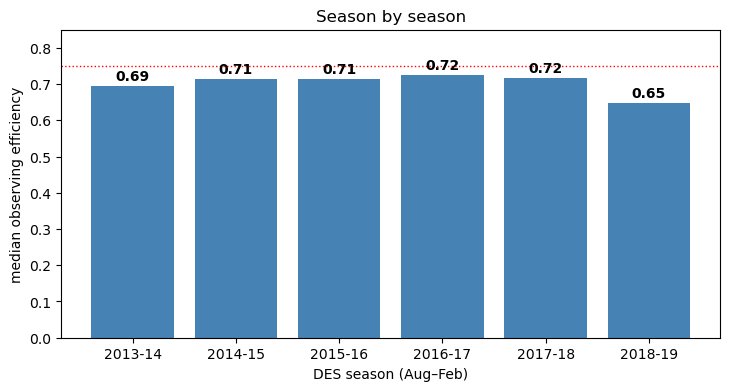

In [6]:
t['season'] = np.where(t['night_dt'].dt.month >= 8,
                       t['night_dt'].dt.year, t['night_dt'].dt.year - 1)
by = t.groupby('season')['efficiency'].median()
labels = [f'{y}-{str(y+1)[2:]}' for y in by.index]

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.bar(labels, by.values, color='steelblue')
ax.axhline(0.75, color='red', ls=':', lw=1)
for i, v in enumerate(by.values):
    ax.text(i, v + 0.015, f'{v:.2f}', ha='center', fontweight='bold')
ax.set_ylim(0, 0.85)
ax.set_ylabel('median observing efficiency')
ax.set_xlabel('DES season (Aug–Feb)')
ax.set_title('Season by season')
plt.show()

**Reading it:** the median night converts a bit over half of its span into open-shutter time, against a hard ~0.75 ceiling set by camera readout. The per-night `efficiency` column is the 0–1 number; the gap between a night's point and the red line in the scatter is time lost to slews, faults, and weather closures — the part a better scheduler can actually win back.

Caveat: "total time" here is first-to-last exposure, not astronomical darkness — a night cut short at both ends still looks efficient. Upgrading the denominator to twilight-to-twilight (sun ephemeris via astropy) is the natural next step.